In [1]:
import os
import numpy as np

import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
from functools import partial
from typing import NamedTuple, Sequence, Callable

import flax.linen as nn
import optax
from soap_jax import soap

import time
import scipy.io
import matplotlib.pyplot as plt

from flax import serialization

from Utilities_talpinn_euler1d import *

In [2]:
# 1. Load Sod shock-tube data
#path = "SodShocktube_data.mat"
path = "LaxShocktube_data.mat"
data = scipy.io.loadmat(path)

sss = 8
Rho0 = jnp.asarray(data["Rho"])[:, ::sss]
U0 = jnp.asarray(data["U"])[:, ::sss]
P0 = jnp.asarray(data["P"])[:, ::sss]
X0 = jnp.asarray(data["X"])[:, ::sss]
T0 = jnp.asarray(data["T"])[:, ::sss]

Nt_test, Nx_test = Rho0.shape
xl = float(X0[0, 0])
xr = float(X0[0, -1])
t0 = float(T0[0, 0])
tend = float(T0[-1, 0])

x_jump = 0.5 * (xl + xr)
ic_params = (float(Rho0[0, 0]), float(U0[0, 0]), float(P0[0, 0]), float(Rho0[0, -1]), float(U0[0, -1]), float(P0[0, -1]))
left_state = ic_params[:3]
right_state = ic_params[3:]

trange = (t0, tend)
xrange = (xl, xr)

T_grid = T0
X_grid = X0

t_test = T0.reshape(-1)
x_test = X0.reshape(-1)

test_labels = jnp.stack([Rho0.reshape(-1), U0.reshape(-1),P0.reshape(-1)], axis=-1)

print(f"Test grid: Nt={Nt_test}, Nx={Nx_test}")
print(f"Time domain: {trange}")
print(f"Space domain: {xrange}")
print(f"Interface position: {x_jump}")
print(f"Left state  [rho,u,p]: {left_state}")
print(f"Right state [rho,u,p]: {right_state}")



Test grid: Nt=129, Nx=257
Time domain: (0.0, 0.14000000059604645)
Space domain: (0.0, 1.0)
Interface position: 0.5
Left state  [rho,u,p]: (0.4449999928474426, 0.6980000138282776, 3.5280001163482666)
Right state [rho,u,p]: (0.5, 0.0, 0.5709999799728394)


In [3]:
# 2. Random keys
seed = 13

save_path = "talpinn_lax02.msgpack"

key = jax.random.PRNGKey(seed)
key_pde_init, key_coor_init, key_train = jax.random.split(key, 3)

# 3. Models
pde_net = Euler_net(n_nodes=40, fourier_dim=20, activation=nn.silu)
pde_params = pde_net.init(key_pde_init, jnp.ones((3,), dtype=T0.dtype))
coor_net = FNN_fourier(layer_sizes=[40, 40, 1], activation=nn.silu, fourier_dim=20)
coor_params = coor_net.init(key_coor_init, jnp.ones((2,), dtype=T0.dtype))

# 4. Optimizers
pde_optimizer = soap(learning_rate=3.0e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)
coor_optimizer = soap(learning_rate=3.0e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)

# 5. Common functions
pde_loss_grad_fn = create_pde_loss_grad_fn(pde_net, w_ic=100.0, gamma=1.4)
coor_loss_grad_fn = create_coor_loss_grad_fn(coor_net, lambda_pos=0.1, xi_x_min=0.05)
eval_fn = create_eval_fn(pde_net)

# Initial affine coordinate mapping
identity_map_xi_to_x, identity_coor_fn = create_identity_maps(xl, xr)

def make_minibatch(map_xi_to_x, coor_fn):
    return create_pde_minibatch_fn(IC_map=IC_vmap, map_xi_to_x=map_xi_to_x, coor_net=coor_fn,
        xL=xl, xR=xr, t0=t0, tend=tend, left_state=left_state, right_state=right_state, x_jump=x_jump)

[Stage 1] JIT warm-up finished.
[Stage 1] iter=00000, time=0.00s | MSE(rho,u,p)=(4.20e-01, 1.99e+00, 3.98e+00) | RL2(rho,u,p)=(1.19e+00, 1.47e+00, 7.88e-01)
[Stage 1] iter=00100, time=1.51s, loss=2.17e+01 | MSE(rho,u,p)=(9.73e-02, 2.21e-01, 2.30e-01) | RL2(rho,u,p)=(5.75e-01, 4.92e-01, 1.89e-01)
[Stage 1] iter=00200, time=2.77s, loss=1.07e+01 | MSE(rho,u,p)=(4.70e-02, 8.99e-02, 1.18e-01) | RL2(rho,u,p)=(3.99e-01, 3.13e-01, 1.36e-01)
[Stage 1] iter=00300, time=4.02s, loss=7.77e+00 | MSE(rho,u,p)=(3.17e-02, 9.33e-02, 9.98e-02) | RL2(rho,u,p)=(3.28e-01, 3.19e-01, 1.25e-01)
[Stage 1] iter=00400, time=5.28s, loss=6.34e+00 | MSE(rho,u,p)=(3.01e-02, 7.40e-02, 8.51e-02) | RL2(rho,u,p)=(3.20e-01, 2.84e-01, 1.15e-01)
[Stage 1] iter=00500, time=6.54s, loss=5.96e+00 | MSE(rho,u,p)=(2.86e-02, 4.95e-02, 7.59e-02) | RL2(rho,u,p)=(3.12e-01, 2.33e-01, 1.09e-01)
[Stage 1] iter=00600, time=7.80s, loss=3.47e+00 | MSE(rho,u,p)=(2.66e-02, 5.50e-02, 8.49e-02) | RL2(rho,u,p)=(3.01e-01, 2.45e-01, 1.15e-01)
[St

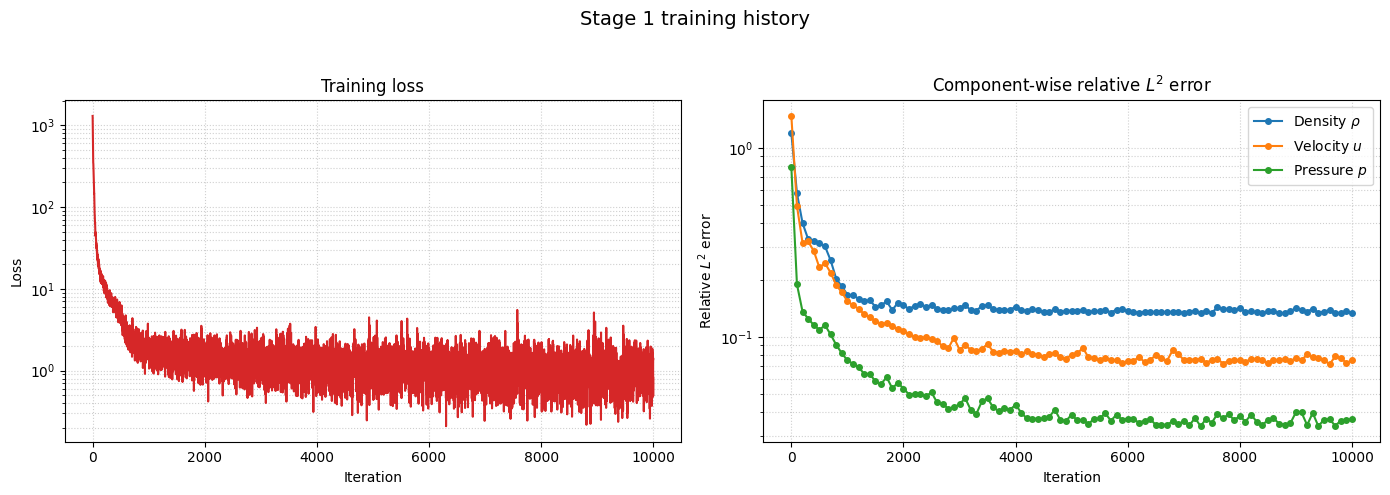

Plotting test grid: nt=129, nx=257
Evaluation errors:
  rho: MSE=5.236185e-03, RL2=1.333640e-01
  u  : MSE=5.184257e-03, RL2=7.526854e-02
  p  : MSE=8.549034e-03, RL2=3.652202e-02


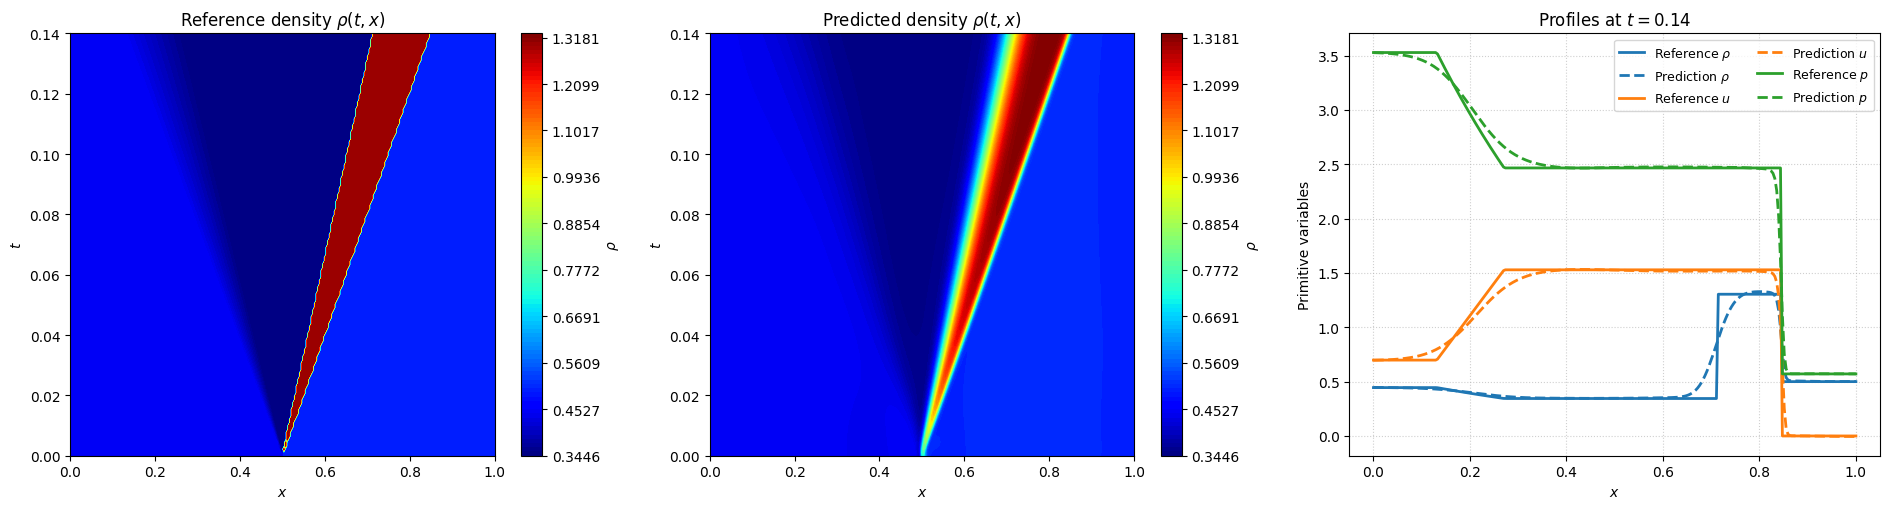

(array([0.00523619, 0.00518426, 0.00854903], dtype=float32),
 array([0.13336404, 0.07526854, 0.03652202], dtype=float32))

In [4]:
test_inputs_stage1 = create_test_inputs(t_test, x_test, identity_coor_fn)
minibatch_stage1 = make_minibatch(identity_map_xi_to_x, identity_coor_fn)

pde_params, key_train, history_stage1 = train_pde_stage(stage_name="Stage 1", 
pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage1,
eval_fn=eval_fn, test_inputs=test_inputs_stage1,  test_labels=test_labels,
key=key_train, nu=3.0e-3, max_iters=10000, pts_pde=10000, pts_ics=1000, max_runtime=10000.0, eval_every=100)
pde_params_stage1 = pde_params

plot_training_history(history_stage1, metric="rl2", title="Stage 1 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, coor_fn=identity_coor_fn)

[Adaptive Mesh] method=integral, time=1.16s
[Coordinate] JIT warm-up finished.
[Coordinate] iter=01000, time=2.02s, batch loss=3.45e-06, full mse=3.71e-06
[Coordinate] iter=02000, time=4.04s, batch loss=4.00e-07, full mse=7.59e-07
[Coordinate] iter=03000, time=6.08s, batch loss=4.74e-07, full mse=4.31e-07
[Coordinate] iter=04000, time=8.11s, batch loss=4.13e-07, full mse=3.01e-07
[Coordinate] iter=05000, time=10.11s, batch loss=3.84e-07, full mse=1.10e-06
[Coordinate] iter=06000, time=12.11s, batch loss=5.53e-07, full mse=4.90e-07
[Coordinate] iter=07000, time=14.12s, batch loss=4.25e-07, full mse=3.96e-07
[Coordinate] iter=08000, time=16.13s, batch loss=2.24e-07, full mse=3.89e-07
[Coordinate] iter=09000, time=18.13s, batch loss=3.70e-07, full mse=3.74e-07
[Coordinate] iter=10000, time=20.14s, batch loss=4.38e-07, full mse=5.34e-07
Coordinate MSE = 5.344582e-07
Coordinate max error = 1.218981e-02
xi_x min = 3.848206e-01
xi_x max = 2.053467e+01
negative xi_x points = 0


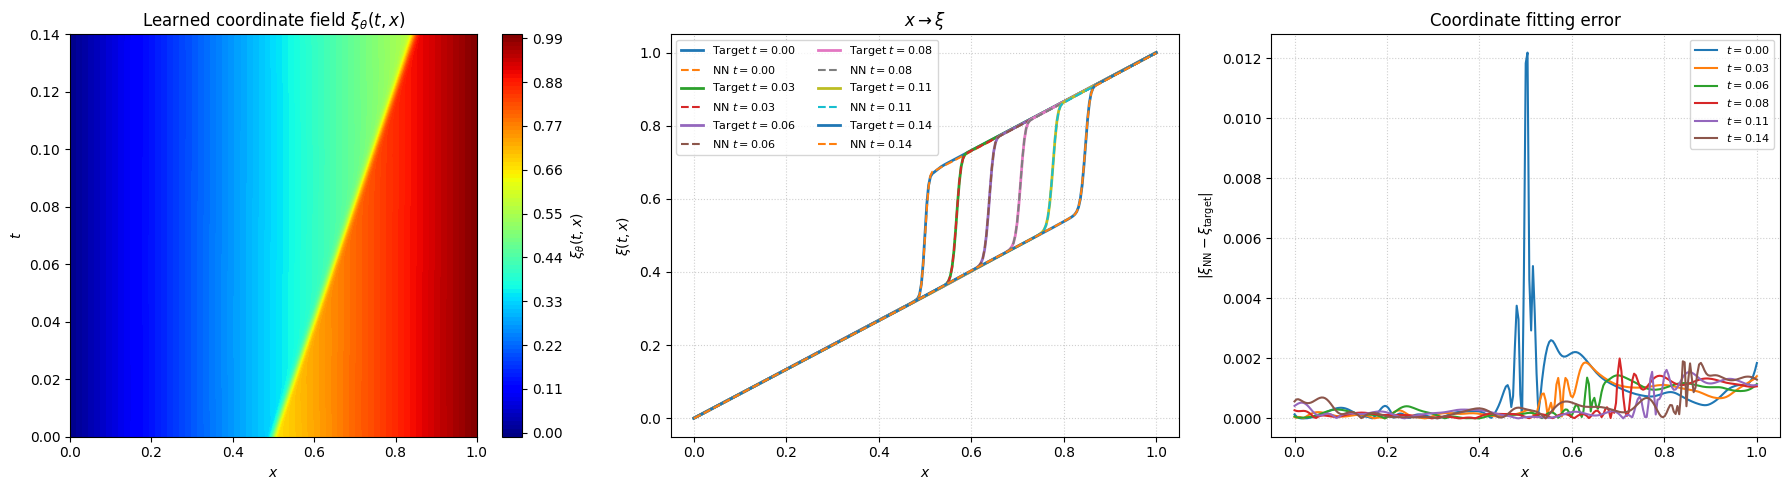

In [5]:
# Generate first adaptive mesh
xi_grid, Xi_of_x, X_adapt, map_xi_to_x, solution_stage1 = generate_adaptive_mesh(pde_net=pde_net, pde_params=pde_params, T_grid=T_grid, X_grid=X_grid, coor_fn=identity_coor_fn,
    mesh_method='integral', winslow_tol=1.0e-5, winslow_max_iter=100000, smooth_steps=4)

# Train first coordinate network
coor_params, key_train = train_coordinate_net(coor_net=coor_net, coor_params=coor_params, coor_optimizer=coor_optimizer, coor_loss_grad_fn=coor_loss_grad_fn, T_grid=T_grid, X_grid=X_grid, Xi_of_x=Xi_of_x,
    key=key_train, max_iters=10000, batch_size=10000, eval_every=1000)
coor_params_stage1 = coor_params

trained_coor_fn = create_coor_fn(coor_net, coor_params)

plot_coordinate_mapping(T_grid=T_grid, X_grid=X_grid, xi_grid=xi_grid, Xi_of_x=Xi_of_x, X_adapt=X_adapt, coor_fn=trained_coor_fn, n_times=6)


[Stage 2] JIT warm-up finished.
[Stage 2] iter=00000, time=0.00s | MSE(rho,u,p)=(5.19e-02, 4.31e-02, 6.72e-02) | RL2(rho,u,p)=(4.20e-01, 2.17e-01, 1.02e-01)
[Stage 2] iter=00100, time=1.35s, loss=1.68e+01 | MSE(rho,u,p)=(3.29e-02, 3.10e-02, 4.73e-02) | RL2(rho,u,p)=(3.34e-01, 1.84e-01, 8.59e-02)
[Stage 2] iter=00200, time=2.65s, loss=4.85e+00 | MSE(rho,u,p)=(1.83e-02, 2.05e-02, 2.42e-02) | RL2(rho,u,p)=(2.49e-01, 1.50e-01, 6.14e-02)
[Stage 2] iter=00300, time=3.94s, loss=1.75e+00 | MSE(rho,u,p)=(8.13e-03, 1.42e-02, 1.96e-02) | RL2(rho,u,p)=(1.66e-01, 1.25e-01, 5.53e-02)
[Stage 2] iter=00400, time=5.24s, loss=1.21e+00 | MSE(rho,u,p)=(5.89e-03, 1.25e-02, 1.70e-02) | RL2(rho,u,p)=(1.41e-01, 1.17e-01, 5.15e-02)
[Stage 2] iter=00500, time=6.53s, loss=1.41e+00 | MSE(rho,u,p)=(5.16e-03, 1.09e-02, 1.47e-02) | RL2(rho,u,p)=(1.32e-01, 1.09e-01, 4.79e-02)
[Stage 2] iter=00600, time=7.82s, loss=6.70e-01 | MSE(rho,u,p)=(4.49e-03, 1.01e-02, 1.38e-02) | RL2(rho,u,p)=(1.24e-01, 1.05e-01, 4.64e-02)
[St

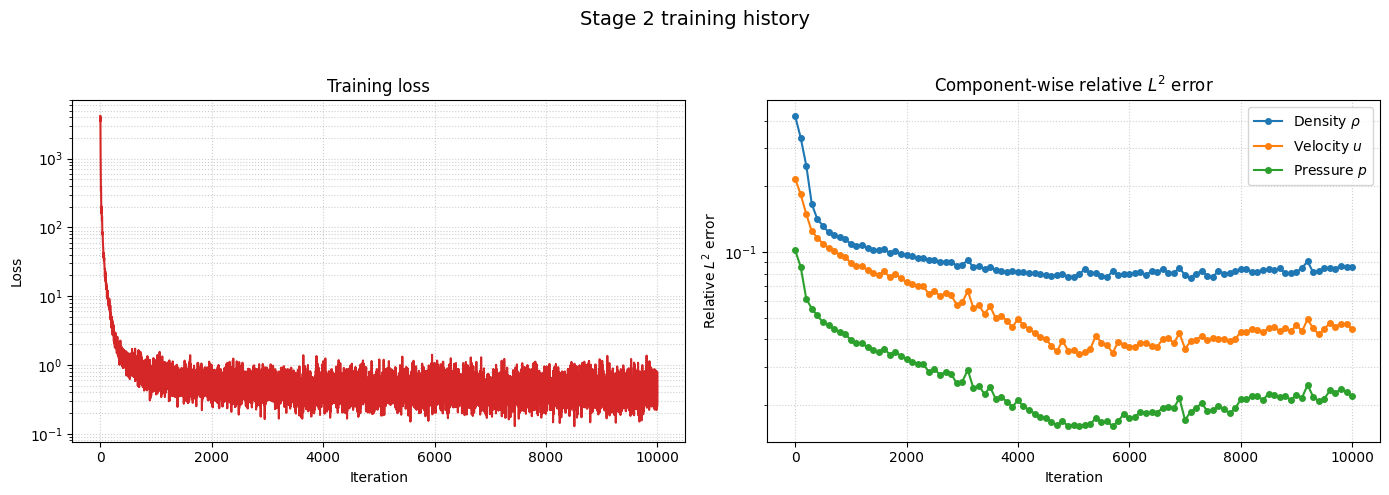

Plotting test grid: nt=129, nx=257
Evaluation errors:
  rho: MSE=2.156178e-03, RL2=8.558025e-02
  u  : MSE=1.821601e-03, RL2=4.461664e-02
  p  : MSE=3.088874e-03, RL2=2.195312e-02


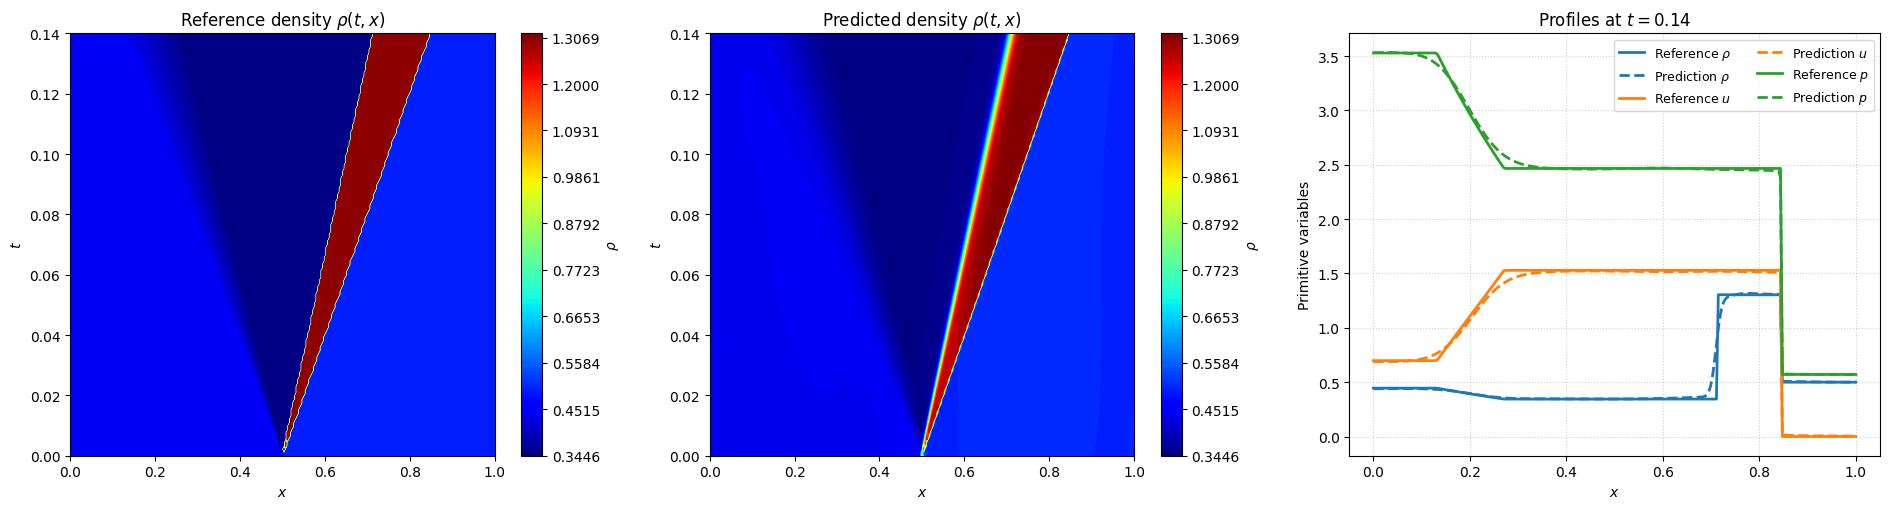

(array([0.00215618, 0.0018216 , 0.00308887], dtype=float32),
 array([0.08558025, 0.04461664, 0.02195312], dtype=float32))

In [6]:
# Stage 2: first adaptive coordinate, nu=1e-3
test_inputs_stage2 = create_test_inputs(t_test, x_test, trained_coor_fn)
minibatch_stage2 = make_minibatch(map_xi_to_x, trained_coor_fn)

pde_params, key_train, history_stage2 = train_pde_stage(stage_name="Stage 2", 
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage2,
    eval_fn=eval_fn, test_inputs=test_inputs_stage2,  test_labels=test_labels,
    key=key_train, nu=3.0e-4, max_iters=10000, pts_pde=10000, pts_ics=1000, max_runtime=10000.0, eval_every=100)
pde_params_stage2 = pde_params

plot_training_history(history_stage2, metric="rl2", title="Stage 2 training history",)

plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, coor_fn=trained_coor_fn)

In [7]:
save_training_results(
        pde_params_by_stage={
            "stage1": pde_params_stage1,
            "stage2": pde_params_stage2,
        },
        coor_params_by_stage={
            "stage1": coor_params_stage1,
        },
        pde_histories_by_stage={
            "stage1": history_stage1,
            "stage2": history_stage2,
        },
        checkpoint_path=save_path,
    )

Training checkpoint saved to: /home/DG21210022/Amon/tal/shocktube/talpinn_lax02.msgpack
Training histories saved to: /home/DG21210022/Amon/tal/shocktube/talpinn_lax02_history.npz
